In [1]:
# https://github.com/langchain-ai/langgraph/blob/main/docs/docs/tutorials/code_assistant/langgraph_code_assistant.ipynb

In [2]:
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader

from langgraph.graph import END, StateGraph, START
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage, RemoveMessage, trim_messages
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

from typing import List
from typing_extensions import TypedDict
import uuid

from IPython.display import Image, display

In [3]:
# LCEL docs
url = "https://python.langchain.com/docs/concepts/lcel/"
loader = RecursiveUrlLoader(
    url=url, max_depth=20, extractor=lambda x: Soup(x, "html.parser").text
)
docs = loader.load()

# Sort the list based on the URLs and get the text
d_sorted = sorted(docs, key=lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))
concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)

In [4]:
concatenated_content[:100]

'\n\n\n\n\nLangChain Expression Language (LCEL) | 🦜️🔗 LangChain\n\n\n\n\n\n\n\n\nSkip to main contentOur Building A'

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

In [ ]:
endpoint = os.getenv("AZURE_OPENAI_SERVICE")
model_name = os.getenv("MODEL_DEPLOYMENT_NAME")
deployment = os.getenv("MODEL_DEPLOYMENT_NAME")
subscription_key = os.getenv("AZURE_OPENAI_CHATGPT_DEPLOYMENT")
api_version = "2024-12-01-preview"


llm_client = AzureChatOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=subscription_key,
    deployment_name=deployment,
    max_tokens=1500
)

In [ ]:
# Grader prompt
code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a coding assistant with expertise in LCEL, LangChain expression language. \n 
    Here is a full set of LCEL documentation:  \n ------- \n  {context} \n ------- \n Answer the user 
    question based on the above provided documentation. Ensure any code you provide can be executed \n 
    with all required imports and variables defined. Structure your answer with a description of the code solution. \n
    Then list the imports. And finally list the functioning code block. Here is the user question:""",
        ),
        ("placeholder", "{messages}"),
    ]
)


# Data model
class code(BaseModel):
    """Schema for code solutions to questions about LCEL."""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Code block import statements")
    code: str = Field(description="Code block not including import statements")


# With your client, you get a function with_structured_output that you can use to get a custom result
# llm_client.with_structured_output(code).invoke()
code_gen_chain_oai = code_gen_prompt | llm_client.with_structured_output(code)
question = "How do I build a RAG chain in LCEL?"
solution = code_gen_chain_oai.invoke(
    {"context": concatenated_content, "messages": [("user", question)]}
)
solution

code(prefix='To build a Retrieval-Augmented Generation (RAG) chain using LCEL, you can leverage composition primitives like RunnableSequence and RunnableParallel to structure the components of retrieval and generation. This approach allows for the optimized and declarative orchestration of the constituent operations.', imports='from langchain_core.runnables import RunnableSequence, RunnableParallel\nfrom langchain_core.llms import ChatModel\nfrom langchain_core.retrievers import VectorStoreRetriever', code='# Instantiate the components for the retrieval system.\nretriever = VectorStoreRetriever(...)\nquery_embedding_generator = ChatModel(...)\nllm = ChatModel(...)\n\n# Define the RAG chain using LCEL.\nrag_chain = RunnableSequence([\n    {"query_embedding": query_embedding_generator, "retrieval_results": retriever} | RunnableParallel,\n    llm\n])\n\n# Invoke the RAG chain with the input query.\nresponse = rag_chain.invoke("Input query for retrieval and generation.")\nprint(response)')

In [7]:
# Creating graph

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        error : Binary flag for control flow to indicate whether test error was tripped
        messages : With user question, error messages, reasoning
        generation : Code solution
        iterations : Number of tries
    """

    error: str
    messages: List
    generation: str
    iterations: int

In [8]:
### Parameter

# Max tries
max_iterations = 3

# Reflect - flag
flag = "reflect" # 'do not reflect'

In [9]:
def generate(state: GraphState):
    """
    Generate a code solution

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation
    """

    print("---GENERATING CODE SOLUTION---")

    # State
    messages = state["messages"]
    iterations = state["iterations"]
    error = state["error"]

    # We have been routed back to generation with an error
    if error == "yes":
        messages += [
            (
                "user",
                "Now, try again. Invoke the code tool to structure the output with a prefix, imports, and code block:",
            )
        ]

    # Solution
    code_solution = code_gen_chain_oai.invoke(
        {"context": concatenated_content, "messages": messages}
    )
    messages += [
        (
            "assistant",
            f"{code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}",
        )
    ]

    # Increment
    iterations = iterations + 1
    return {"generation": code_solution, "messages": messages, "iterations": iterations}


In [10]:
def code_check(state: GraphState):
    """
    Check code

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, error
    """

    print("---CHECKING CODE---")

    # State
    messages = state["messages"]
    code_solution = state["generation"]
    iterations = state["iterations"]

    # Get solution components
    imports = code_solution.imports
    code = code_solution.code

    # Check imports
    try:
        exec(imports)
    except Exception as e:
        print("---CODE IMPORT CHECK: FAILED---")
        error_message = [("user", f"Your solution failed the import test: {e}")]
        messages += error_message
        return {
            "generation": code_solution,
            "messages": messages,
            "iterations": iterations,
            "error": "yes",
        }

    # Check execution
    try:
        exec(imports + "\n" + code)
    except Exception as e:
        print("---CODE BLOCK CHECK: FAILED---")
        error_message = [("user", f"Your solution failed the code execution test: {e}")]
        messages += error_message
        return {
            "generation": code_solution,
            "messages": messages,
            "iterations": iterations,
            "error": "yes",
        }

    # No errors
    print("---NO CODE TEST FAILURES---")
    return {
        "generation": code_solution,
        "messages": messages,
        "iterations": iterations,
        "error": "no",
    }

In [11]:
def reflect(state: GraphState):
    """
    Reflect on errors

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation
    """

    print("---GENERATING CODE SOLUTION---")

    # State
    messages = state["messages"]
    iterations = state["iterations"]
    code_solution = state["generation"]


    # Add reflection
    reflections = code_gen_chain_oai.invoke(
        {"context": concatenated_content, "messages": messages}
    )
    messages += [("assistant", f"Here are reflections on the error: {reflections}")]
    return {"generation": code_solution, "messages": messages, "iterations": iterations}


In [12]:
# Edge control function

def decide_to_finish(state: GraphState):
    """
    Determines whether to finish.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    error = state["error"]
    iterations = state["iterations"]

    if error == "no" or iterations == max_iterations:
        print("---DECISION: FINISH---")
        return "end"
    else:
        print("---DECISION: RE-TRY SOLUTION---")
        if flag == "reflect":
            return "reflect"
        else:
            return "generate"

In [13]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("generate", generate)  
workflow.add_node("check_code", code_check)
workflow.add_node("reflect", reflect) 

# Build graph
workflow.add_edge(START, "generate")
workflow.add_edge("generate", "check_code")
workflow.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        "end": END,
        "reflect": "reflect",
        # "generate": "generate",
    },
)
workflow.add_edge("reflect", "generate")
app = workflow.compile()

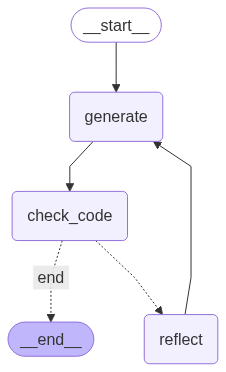

In [14]:
# View
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
question = "How can I directly pass a string to a runnable and use it to construct the input needed for my prompt?"
solution = app.invoke({"messages": [("user", question)], "iterations": 0, "error": ""})

---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---GENERATING CODE SOLUTION---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---GENERATING CODE SOLUTION---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: FINISH---


In [16]:
import pprint
pprint.pp(solution["generation"].code)

('# Define the first runnable to process input strings\n'
 "formatter_runnable = RunnableLambda(lambda x: {'formatted_value': "
 "f'Processed input: {x}'})\n"
 '\n'
 '# Define a second runnable to further process the output\n'
 'next_runnable = RunnableLambda(lambda input_dict: '
 "input_dict['formatted_value'].upper())\n"
 '\n'
 '# Combine them into a sequence\n'
 'final_chain = RunnableSequence([formatter_runnable, next_runnable])\n'
 '\n'
 '# Invoke the chain with input text\n'
 'input_text = "Example input"\n'
 'output = final_chain.invoke(input_text)\n'
 '\n'
 '# Print the result\n'
 'print(output)')


In [17]:
# No history of code generation or message is saved, the LLM has to work with the last code generation/message
# Also, when reflecting, the trigger point is user input, but we provide user input in code directly.

In [18]:
# Handling messages with conversational agents - 
# 1. Removing messages from our stack
# 2. Trimming messages based on a strategy + token capacity

In [19]:
# Removing messages from our stack before sending it to the LLM

# Nodes
def filter_messages(state: GraphState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

In [20]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("filter_message", filter_messages)
workflow.add_node("generate", generate)  
workflow.add_node("check_code", code_check)
workflow.add_node("reflect", reflect) 

# Build graph
workflow.add_edge(START, "filter_message")
workflow.add_edge("filter_message", "generate")
workflow.add_edge("generate", "check_code")
workflow.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        "end": END,
        "reflect": "reflect",
        "generate": "generate",
    },
)
workflow.add_edge("reflect", "generate")
app = workflow.compile()

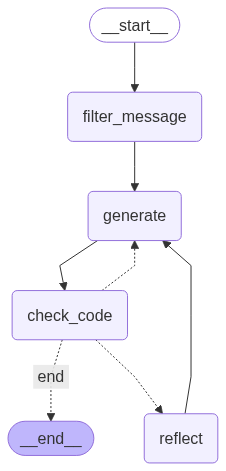

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
question = "How can I directly pass a string to a runnable and use it to construct the input needed for my prompt?"
solution = app.invoke({"messages": [("user", question)], "iterations": 0, "error": ""})

---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---GENERATING CODE SOLUTION---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---GENERATING CODE SOLUTION---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: FINISH---


In [23]:
# Trimming messages 

# Node
def chat_model_filter(state: GraphState):
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=code_gen_chain_oai, # you can provide model client or token counter function
        max_tokens=384,
        start_on="human",
        end_on=("human", "tool"),
    )
    return {"messages": [code_gen_chain_oai.invoke(trimmed_messages)]}

In [24]:
# Adding functionality to run long conversation through summarization - 

# For this we will need to change our state to hold summaries too and additional nodes to handle the summary

In [25]:
# Creating graph

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        error : Binary flag for control flow to indicate whether test error was tripped
        messages : With user question, error messages, reasoning
        generation : Code solution
        iterations : Number of tries
    """

    error: str
    messages: List
    generation: str
    iterations: int
    summary: str

In [81]:
max_iterations = 4
flag = "reflect"

In [83]:
def generate(state: GraphState):
    """
    Generate a code solution

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation
    """

    print("---GENERATING CODE SOLUTION---")

    # State
    messages = state["messages"]
    iterations = state["iterations"]
    error = state["error"]
    summary = state.get("summary", "")

    if summary:

        # We have been routed back to generation with an error
        if error == "yes":
            messages += [
                SystemMessage(content=f"Summary of conversation earlier: {summary}"),
                HumanMessage(content="Now, try again. Invoke the code tool to structure the output with a prefix, imports, and code block:")
            ]
            
    else:
        if error == "yes":
            messages += [HumanMessage(content="Now, try again. Invoke the code tool to structure the output with a prefix, imports, and code block:")]


    # Solution
    code_solution = code_gen_chain_oai.invoke(
        {"context": concatenated_content, "messages": messages}
    )
    messages += [AIMessage(content=f"{code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}")]

    # Increment
    iterations = iterations + 1
    return {"generation": code_solution, "messages": messages, "iterations": iterations}

In [84]:
def code_check(state: GraphState):
    """
    Check code

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, error
    """

    print("---CHECKING CODE---")

    # State
    messages = state["messages"]
    code_solution = state["generation"]
    iterations = state["iterations"]

    # Get solution components
    imports = code_solution.imports
    code = code_solution.code

    # Check imports
    try:
        exec(imports)
    except Exception as e:
        print("---CODE IMPORT CHECK: FAILED---")
        error_message = [HumanMessage(content=f"Your solution failed the import test: {e}")]
        messages += error_message
        return {
            "generation": code_solution,
            "messages": messages,
            "iterations": iterations,
            "error": "yes",
        }

    # Check execution
    try:
        exec(imports + "\n" + code)
    except Exception as e:
        print("---CODE BLOCK CHECK: FAILED---")
        error_message = [HumanMessage(content=f"Your solution failed the code execution test: {e}")]
        messages += error_message
        return {
            "generation": code_solution,
            "messages": messages,
            "iterations": iterations,
            "error": "yes",
        }

    # No errors
    print("---NO CODE TEST FAILURES---")
    return {
        "generation": code_solution,
        "messages": messages,
        "iterations": iterations,
        "error": "no",
    }

In [85]:
def reflect(state: GraphState):
    """
    Reflect on errors

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation
    """

    print("---DELIBERATING ON CODE SOLUTION---")

    # State
    messages = state["messages"]
    iterations = state["iterations"]
    code_solution = state["generation"]

    system = SystemMessage(content="Reflect on the history for the code and the " \
    "error user said they encountered and provide insights as to how to fix them")


    # Add reflection
    reflections = llm_client.invoke([system] + messages)
    
    messages += [("assistant", f"Here are reflections on the error: {reflections}")]
    return {"generation": code_solution, "messages": messages, "iterations": iterations}

In [86]:
def summarize_conversation(state: GraphState):
    
    print("---SUMMARIZING MESSAGES---")

    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm_client.invoke(messages)
    
    # Delete all but the 2 most recent messages
    deleted_messages = state["messages"][:-2]
    return {"summary": response.content, "messages": deleted_messages}

In [87]:
def should_summarize(state: GraphState):
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize"
    
    # Otherwise we can just end
    return "generate"

In [88]:
def decide_to_finish(state: GraphState):
    """
    Determines whether to finish.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    error = state["error"]
    iterations = state["iterations"]

    if error == "no" or iterations == max_iterations:
        print("---DECISION: FINISH---")
        return "end"
    else:
        print("---DECISION: RE-TRY SOLUTION---")
        return "reflect"

In [89]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("generate", generate)  
workflow.add_node("check_code", code_check)
workflow.add_node("reflect", reflect) 
workflow.add_node("summarize", summarize_conversation)

# Build graph
workflow.add_edge(START, "generate")
workflow.add_edge("generate", "check_code")
workflow.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        "end": END,
        "reflect": "reflect",
    },
)
workflow.add_conditional_edges(
    "reflect",
    should_summarize,
    {
        "summarize": "summarize",
        "generate": "generate",
    },
)
workflow.add_edge("summarize", "generate")

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

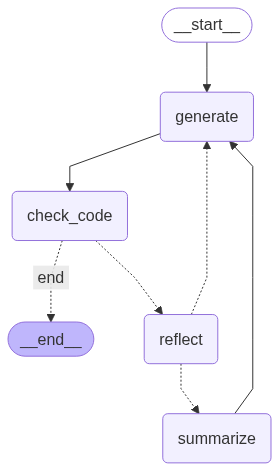

In [90]:
# View
display(Image(app.get_graph().draw_mermaid_png()))

In [91]:
# Create a thread
thread = uuid.uuid4()
config = {"configurable": {"thread_id": thread}}

In [92]:
# Start conversation
input_message = HumanMessage(content="Write a recursive function using in-built python functions")

output = app.invoke({"messages": [input_message], "iterations": 0, "error": ""}, config=config) 
for m in output['messages'][-1:]:
    m.pretty_print()

---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---DELIBERATING ON CODE SOLUTION---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE IMPORT CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---DELIBERATING ON CODE SOLUTION---
---SUMMARIZING MESSAGES---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: RE-TRY SOLUTION---
---DELIBERATING ON CODE SOLUTION---
---SUMMARIZING MESSAGES---
---GENERATING CODE SOLUTION---
---CHECKING CODE---
---CODE BLOCK CHECK: FAILED---
---DECISION: FINISH---
================================ Human Message =================================

Your solution failed the code execution test: name 'factorial' is not defined


In [95]:
app.get_state(config).values.get("summary","")

'### Extended Summary of the Conversation:\n\n1. **Initial User Request**: The user initially asked for a recursive Python function implemented with built-in Python features.\n\n2. **First Attempt**: The assistant provided a recursive factorial function. However, the user reported an execution error: `"NameError: name \'factorial\' is not defined"`, suggesting that the function was either incorrectly implemented or not recognized by the interpreter.\n\n3. **Revised Explanation and Fixed Code**: The assistant diagnosed the issue, suggesting potential causes such as the function being called before its definition. It provided a revised factorial function and explained how to execute it properly. Despite these efforts, the user reported a new error: `"unterminated string literal (detected at line 1)"`, indicating possibly malformed code provided in earlier responses.\n\n4. **Further Attempts to Fix**: The assistant attempted to refine the solution further. It introduced clearer structurin

In [96]:
app.get_state(config).values.get("messages","")

[HumanMessage(content='Write a recursive function using in-built python functions', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Below is a recursive python function implementation. \n Imports: # No special library imports are needed as we are using built-in functionality. \n Code: def factorial(n):\n    """\n    Recursive function to calculate the factorial of a number.\n    Args:\n        n (int): Non-negative integer whose factorial is to be computed.\n    Returns:\n        int: Factorial of the input integer.\n    """\n    if n == 0:\n        return 1  # Base case: factorial of 0 is 1.\n    else:\n        return n * factorial(n - 1)  # Recursive call: n! = n * (n-1)!\n\n# Example Usage\nnumber = 5\nprint(f"The factorial of {number} is {factorial(number)}.")', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="Your solution failed the code execution test: name 'factorial' is not defined", additional_kwargs={}, response_metadata={}),
 ['assistant'